In [35]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import matplotlib.patches as patches

# ─────────────────────────────────────────────
# Parameters
# ─────────────────────────────────────────────
alpha        = 0.1
T            = 0.4
nx           = 100
nt           = 800
x_fd         = np.linspace(0, 1, nx)
t_fd         = np.linspace(0, T, nt)
dx           = x_fd[1] - x_fd[0]
dt           = t_fd[1] - t_fd[0]
n_nb         = 6
n_int        = 20000
box_init     = 0.05
box_max      = 0.4
box_expand   = 1.5
w1_thresh    = 5
n_seeds      = 100    # interior seed points with true values

# ─────────────────────────────────────────────
# True solution
# ─────────────────────────────────────────────
def u_true(x, t):
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x)

# ─────────────────────────────────────────────
# FD reference solution
# ─────────────────────────────────────────────
r = alpha * dt / dx**2
print(f"CFL number: {r:.4f}  (must be <= 0.5)")

U_fd = np.zeros((nt, nx))
U_fd[0, :] = np.sin(np.pi * x_fd)
U_fd[:, 0] = 0.0; U_fd[:,-1] = 0.0
for k in range(nt - 1):
    U_fd[k+1, 1:-1] = (U_fd[k, 1:-1]
                       + r * (U_fd[k, 2:] - 2*U_fd[k, 1:-1] + U_fd[k, :-2]))

# ─────────────────────────────────────────────
# Weight solver with PDE constraint
# ─────────────────────────────────────────────
def compute_weights(dx_nb, dt_nb, alpha):
    A = np.vstack([
        np.ones(len(dx_nb)),
        dx_nb,
        dt_nb,
        dt_nb - alpha * dx_nb**2
    ])
    b = np.array([1.0, 0.0, 0.0, 0.0])
    w, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    return w

# ─────────────────────────────────────────────
# Find neighbours (causal)
# ─────────────────────────────────────────────
def find_neighbours(xq, tq, visited_x, visited_t, n_needed=5):
    causal = visited_t <= tq
    cx, ct = visited_x[causal], visited_t[causal]
    box = box_init
    while box <= box_max:
        mask = (np.abs(cx - xq) <= box) & (np.abs(ct - tq) <= box)
        idx  = np.where(mask)[0]
        if len(idx) >= n_needed:
            dists   = np.sqrt((cx[idx]-xq)**2 + (ct[idx]-tq)**2)
            nearest = idx[np.argsort(dists)[:n_needed]]
            causal_idx = np.where(causal)[0]
            return causal_idx[nearest]
        box *= box_expand
    return None

# ─────────────────────────────────────────────
# Initialise: IC + BC + interior seeds
# ─────────────────────────────────────────────
# IC
ic_x = np.linspace(0, 1, 100)
ic_t = np.zeros(100)
ic_u = u_true(ic_x, ic_t)

# BC
bc_t   = np.linspace(0, T, 20)
bc_x_l = np.zeros(20);  bc_u_l = np.zeros(20)
bc_x_r = np.ones(20);   bc_u_r = np.zeros(20)

# Interior seeds — true values at random interior points
# spread across the full (x, t) domain to scaffold the rollout
rng_seed  = np.random.default_rng(7)
seed_x    = rng_seed.uniform(0.05, 0.95, n_seeds)
seed_t    = rng_seed.uniform(0.01, T,    n_seeds)
seed_u    = u_true(seed_x, seed_t)

vis_x = np.concatenate([ic_x, bc_x_l, bc_x_r, seed_x])
vis_t = np.concatenate([ic_t, bc_t,   bc_t,   seed_t])
vis_u = np.concatenate([ic_u, bc_u_l, bc_u_r, seed_u])

# Track which are seeds so we can mark them in the plot
n_ic_bc = len(ic_x) + len(bc_x_l) + len(bc_x_r)

# ─────────────────────────────────────────────
# Generate candidate interior points
# ─────────────────────────────────────────────
rng    = np.random.default_rng(42)
cand_x = rng.uniform(0.02, 0.98, n_int * 5)
cand_t = rng.uniform(0.01, T,    n_int * 5)
order  = np.argsort(cand_t)
cand_x = cand_x[order]
cand_t = cand_t[order]

# ─────────────────────────────────────────────
# Rollout
# ─────────────────────────────────────────────
visited_order_x   = []
visited_order_t   = []
visited_order_u   = []
visited_order_err = []
skipped = 0

for xq, tq in zip(cand_x, cand_t):
    if len(visited_order_x) >= n_int:
        break

    idx = find_neighbours(xq, tq, vis_x, vis_t, n_needed=n_nb)
    if idx is None:
        skipped += 1
        continue

    dx_nb = vis_x[idx] - xq
    dt_nb = vis_t[idx] - tq
    w     = compute_weights(dx_nb, dt_nb, alpha)
    if np.sum(np.abs(w)) > w1_thresh:
        skipped += 1
        continue

    u_pred = w @ vis_u[idx]
    u_ref  = u_true(xq, tq)
    err    = abs(u_pred - u_ref)

    vis_x = np.append(vis_x, xq)
    vis_t = np.append(vis_t, tq)
    vis_u = np.append(vis_u, u_pred)

    visited_order_x.append(xq)
    visited_order_t.append(tq)
    visited_order_u.append(u_pred)
    visited_order_err.append(err)

visited_order_x   = np.array(visited_order_x)
visited_order_t   = np.array(visited_order_t)
visited_order_u   = np.array(visited_order_u)
visited_order_err = np.array(visited_order_err)

print(f"Seeds:   {n_seeds}")
print(f"Visited: {len(visited_order_x)}  |  Skipped: {skipped}")
print(f"Mean error: {visited_order_err.mean():.4e}")
print(f"Max  error: {visited_order_err.max():.4e}")


CFL number: 0.4907  (must be <= 0.5)
Seeds:   100
Visited: 13733  |  Skipped: 86267
Mean error: 5.5954e-01
Max  error: 3.8609e+01


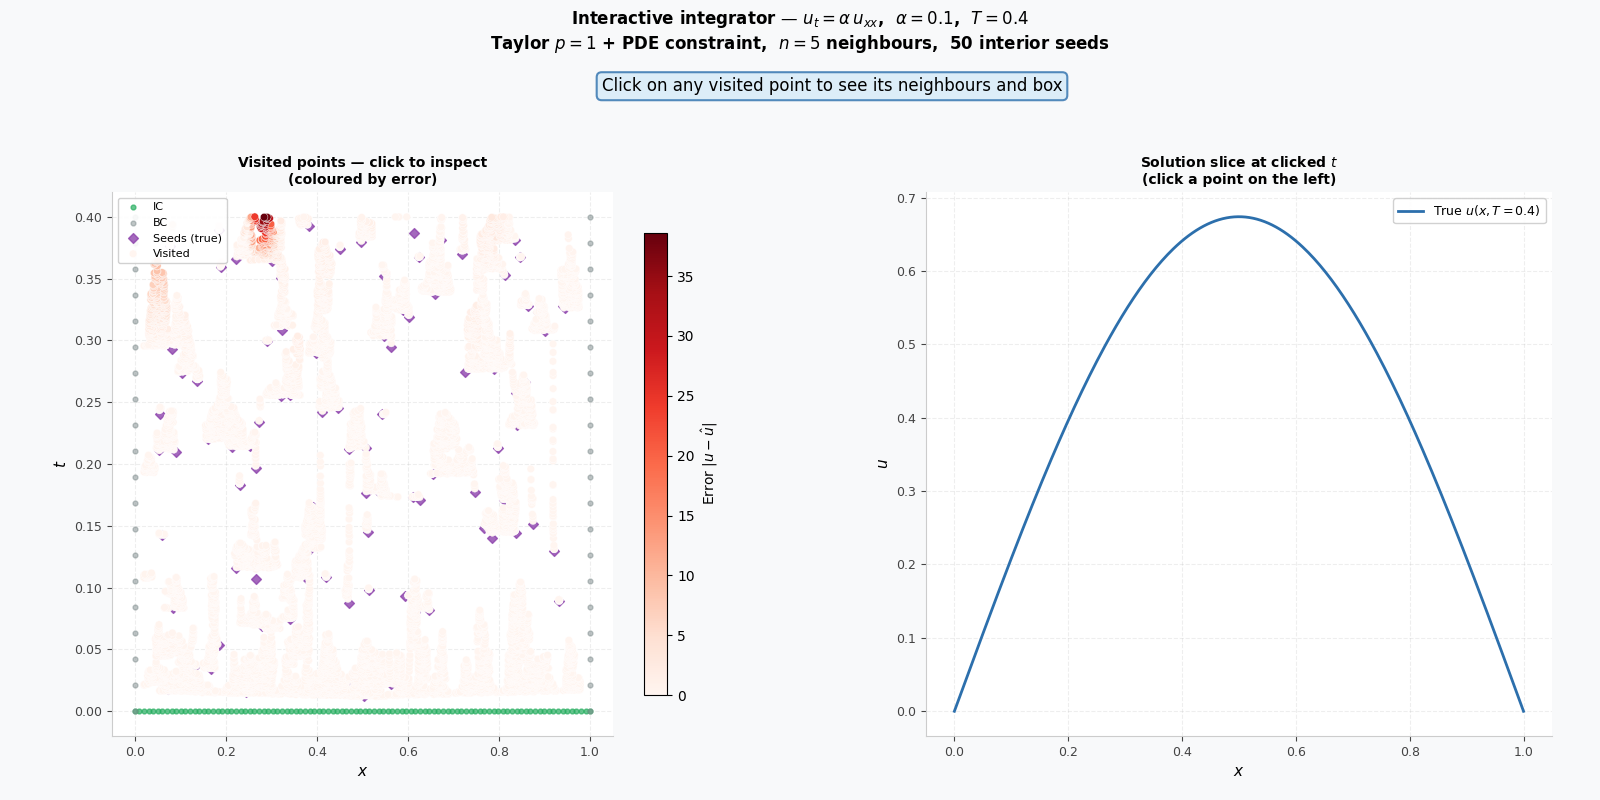

In [36]:
# ─────────────────────────────────────────────
# Interactive visualization
# ─────────────────────────────────────────────
BLUE   = '#2C6FAC'
ORANGE = '#E87722'
RED    = '#C0392B'
GREEN  = '#27AE60'
GREY   = '#7F8C8D'
PURPLE = '#8E44AD'

fig = plt.figure(figsize=(16, 8))
gs  = gridspec.GridSpec(2, 2, height_ratios=[0.1, 0.9],
                        hspace=0.25, wspace=0.3,
                        left=0.07, right=0.97, top=0.93, bottom=0.08)
fig.patch.set_facecolor('#F8F9FA')

ax_text = fig.add_subplot(gs[0, :])
ax_text.axis('off')
text_display = ax_text.text(
    0.5, 0.5, 'Click on any visited point to see its neighbours and box',
    ha='center', va='center', fontsize=12,
    bbox=dict(boxstyle='round', facecolor='#D6EAF8',
              alpha=0.8, edgecolor=BLUE, linewidth=1.5)
)

ax_left  = fig.add_subplot(gs[1, 0])
ax_right = fig.add_subplot(gs[1, 1])

def style_ax(ax):
    ax.set_facecolor('white')
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#CCCCCC')
    ax.tick_params(colors='#444444', labelsize=9)
    ax.grid(True, alpha=0.2, linestyle='--', color='#AAAAAA')

style_ax(ax_left); style_ax(ax_right)

# IC
ax_left.scatter(ic_x, ic_t, s=12, color=GREEN, zorder=3, label='IC', alpha=0.7)
# BC
ax_left.scatter(np.concatenate([bc_x_l, bc_x_r]),
                np.concatenate([bc_t, bc_t]),
                s=12, color=GREY, zorder=3, label='BC', alpha=0.5)
# Seeds
ax_left.scatter(seed_x, seed_t, s=25, color=PURPLE, zorder=3,
                marker='D', label='Seeds (true)', alpha=0.8)
# Visited
sc = ax_left.scatter(
    visited_order_x, visited_order_t,
    c=visited_order_err, cmap='Reds', s=30, zorder=4,
    edgecolors='white', linewidths=0.3,
    norm=Normalize(vmin=0, vmax=max(visited_order_err.max(), 1e-10)),
    picker=True, label='Visited'
)
plt.colorbar(sc, ax=ax_left, label='Error $|u - \\hat{u}|$', shrink=0.85)

ax_left.set_xlabel('$x$', fontsize=11)
ax_left.set_ylabel('$t$', fontsize=11)
ax_left.set_title('Visited points — click to inspect\n(coloured by error)',
                  fontsize=10, fontweight='bold')
ax_left.legend(fontsize=8, framealpha=0.9, edgecolor='#CCCCCC')

x_plot = np.linspace(0, 1, 300)
ax_right.plot(x_plot, u_true(x_plot, T), '-', color=BLUE,
              linewidth=2, label=f'True $u(x, T={T})$')
ax_right.set_xlabel('$x$', fontsize=11)
ax_right.set_ylabel('$u$', fontsize=11)
ax_right.set_title('Solution slice at clicked $t$\n(click a point on the left)',
                   fontsize=10, fontweight='bold')
ax_right.legend(fontsize=9, framealpha=0.9, edgecolor='#CCCCCC')

_interactive_artists = []

def clear_interactive():
    for artist in _interactive_artists:
        try: artist.remove()
        except: pass
    _interactive_artists.clear()

def on_click(event):
    if event.inaxes != ax_left or event.button != 1:
        return
    xc, tc = event.xdata, event.ydata
    if xc is None or tc is None:
        return

    dists = np.sqrt((visited_order_x - xc)**2 + (visited_order_t - tc)**2)
    idx   = int(np.argmin(dists))
    x_range = ax_left.get_xlim()[1] - ax_left.get_xlim()[0]
    y_range = ax_left.get_ylim()[1] - ax_left.get_ylim()[0]
    if dists[idx] > max(x_range, y_range) * 0.03:
        return

    xq = visited_order_x[idx]
    tq = visited_order_t[idx]
    uq = visited_order_u[idx]
    eq = visited_order_err[idx]

    clear_interactive()

    nb_idx_full = find_neighbours(xq, tq, vis_x, vis_t, n_needed=n_nb)
    if nb_idx_full is not None:
        box_size = max(
            np.max(np.abs(vis_x[nb_idx_full] - xq)),
            np.max(np.abs(vis_t[nb_idx_full] - tq))
        )
        rect = patches.Rectangle(
            (xq - box_size, tq - box_size), 2*box_size, 2*box_size,
            linewidth=1.8, edgecolor=RED, facecolor=RED, alpha=0.07, zorder=2
        )
        ax_left.add_patch(rect)
        _interactive_artists.append(rect)

        for ni in nb_idx_full:
            line, = ax_left.plot([xq, vis_x[ni]], [tq, vis_t[ni]],
                                 '-', color=BLUE, linewidth=1.2, alpha=0.5, zorder=3)
            _interactive_artists.append(line)

        nb_sc = ax_left.scatter(vis_x[nb_idx_full], vis_t[nb_idx_full],
                                s=80, color=BLUE, marker='s', zorder=5,
                                edgecolors='white', linewidths=0.8)
        _interactive_artists.append(nb_sc)

    node = ax_left.scatter([xq], [tq], s=180, color=RED, marker='o', zorder=6,
                           edgecolors='black', linewidths=1.2)
    _interactive_artists.append(node)

    text_display.set_text(
        f'Point: ({xq:.3f}, {tq:.3f})  |  '
        f'Predicted: {uq:.5f}  |  '
        f'True: {u_true(xq, tq):.5f}  |  '
        f'Error: {eq:.2e}'
    )

    ax_right.cla(); style_ax(ax_right)
    ax_right.plot(x_plot, u_true(x_plot, tq), '-', color=BLUE,
                  linewidth=2, label=f'True $u(x, t={tq:.3f})$')
    t_tol = 0.03
    mask  = np.abs(visited_order_t - tq) < t_tol
    if mask.sum() > 0:
        ax_right.scatter(visited_order_x[mask], visited_order_u[mask],
                         s=40, color=ORANGE, zorder=4,
                         edgecolors='white', linewidths=0.4,
                         label=f'Integrator ($t\\approx{tq:.3f}$)')
    ax_right.scatter([xq], [uq], s=150, color=RED, zorder=5,
                     marker='*', edgecolors='black', linewidths=0.8,
                     label='Clicked point')
    ax_right.set_xlabel('$x$', fontsize=11)
    ax_right.set_ylabel('$u$', fontsize=11)
    ax_right.set_title(f'Solution slice at $t = {tq:.3f}$', fontsize=10, fontweight='bold')
    ax_right.legend(fontsize=8.5, framealpha=0.9, edgecolor='#CCCCCC')
    fig.canvas.draw()

fig.canvas.mpl_connect('button_press_event', on_click)

fig.suptitle(
    r'Interactive integrator — $u_t = \alpha\,u_{xx}$,  $\alpha=0.1$,  $T=0.4$'
    '\n'
    r'Taylor $p=1$ + PDE constraint,  $n=5$ neighbours,  50 interior seeds',
    fontsize=12, fontweight='bold', y=0.99
)

plt.show()










Running seed sweep...
  seeds=  0  visited= 134  mean_err=2.229e-02  max_err=7.281e-02
  seeds=  5  visited= 173  mean_err=1.856e-02  max_err=7.281e-02
  seeds= 10  visited= 202  mean_err=1.812e-02  max_err=7.281e-02
  seeds= 20  visited= 389  mean_err=1.096e-02  max_err=7.384e-02
  seeds= 50  visited= 500  mean_err=4.824e-03  max_err=2.939e-02
  seeds=100  visited= 500  mean_err=2.798e-02  max_err=1.248e+00
  seeds=200  visited= 500  mean_err=3.481e-03  max_err=4.405e-02

Running main rollout (50 seeds)...
Visited: 500  |  Skipped: 3843
Mean error: 4.8243e-03  |  Max error: 2.9395e-02


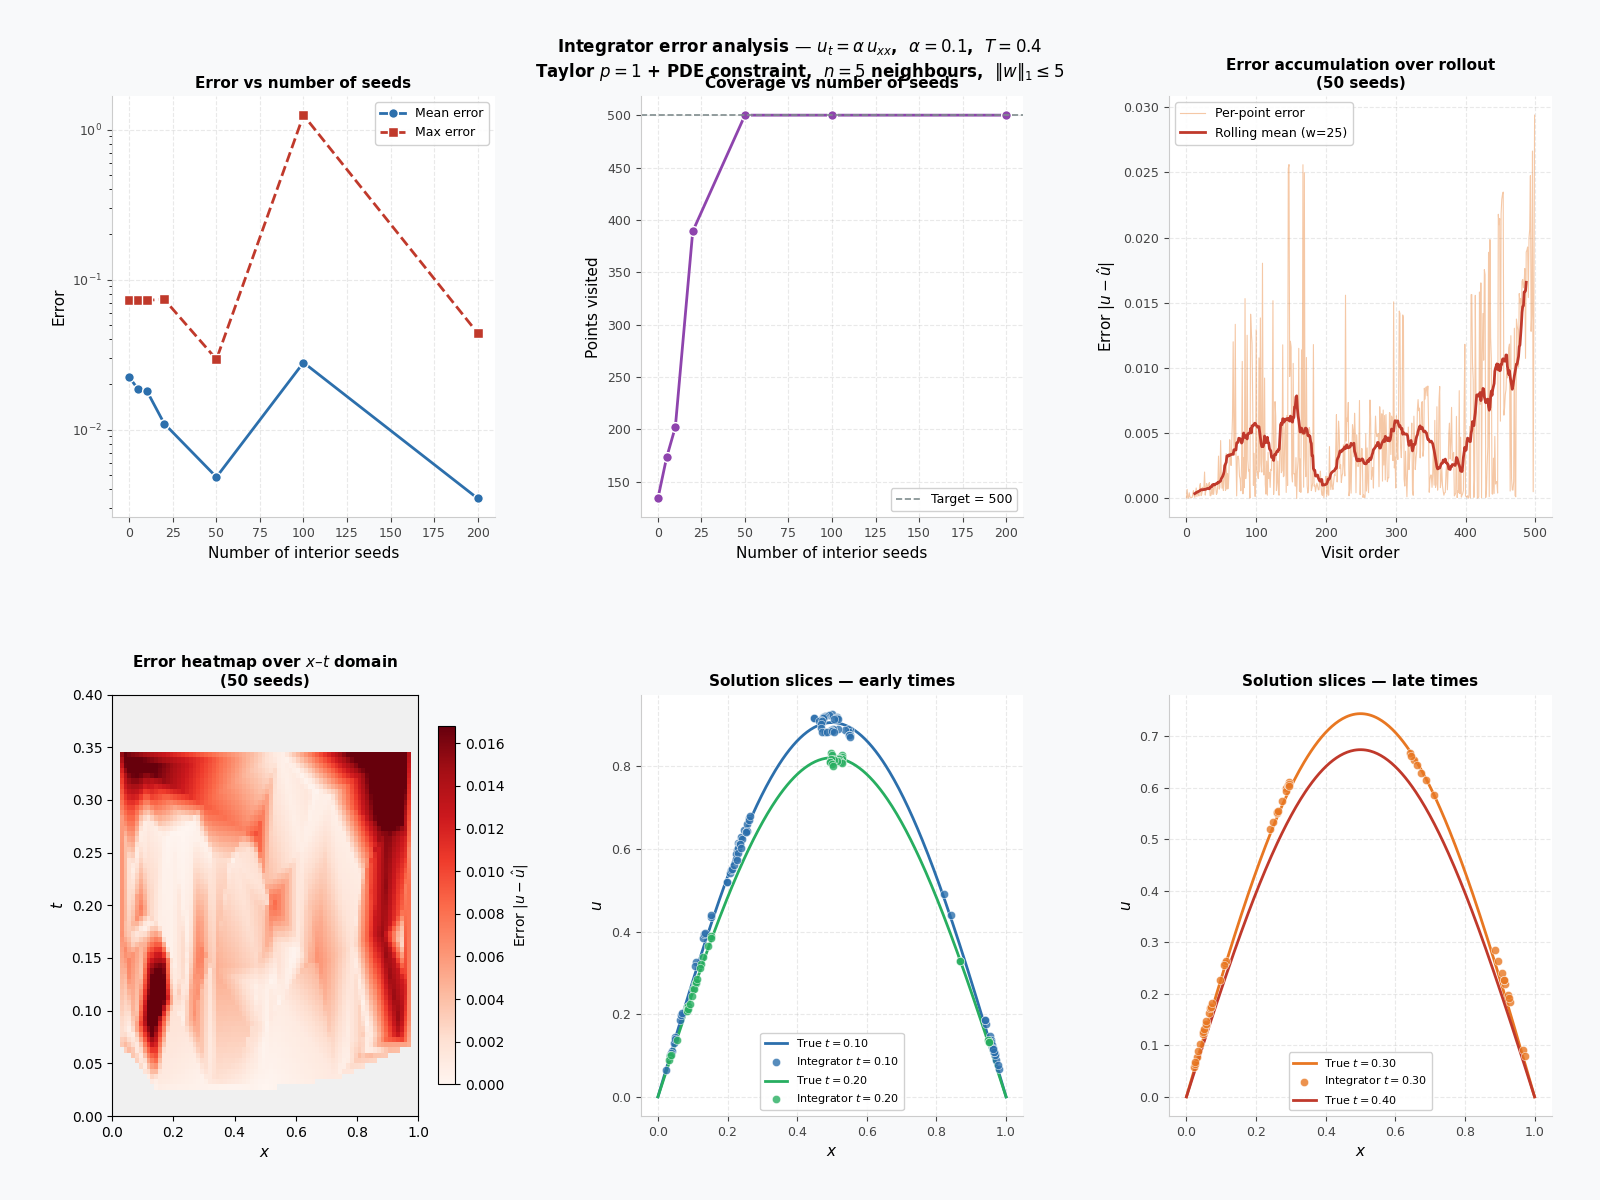

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from scipy.interpolate import griddata

# ─────────────────────────────────────────────
# Parameters
# ─────────────────────────────────────────────
alpha      = 0.1
T          = 0.4
nx         = 100
nt         = 8000
x_fd       = np.linspace(0, 1, nx)
t_fd       = np.linspace(0, T, nt)
dx         = x_fd[1] - x_fd[0]
dt         = t_fd[1] - t_fd[0]
n_nb       = 5
n_int      = 500      # interior points to visit per run
box_init   = 0.05
box_max    = 0.4
box_expand = 1.5
w1_thresh  = 5

def u_true(x, t):
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x)

# ─────────────────────────────────────────────
# Weight solver
# ─────────────────────────────────────────────
def compute_weights(dx_nb, dt_nb):
    A = np.vstack([
        np.ones(len(dx_nb)),
        dx_nb,
        dt_nb,
        dt_nb - alpha * dx_nb**2
    ])
    b = np.array([1.0, 0.0, 0.0, 0.0])
    w, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    return w

# ─────────────────────────────────────────────
# Neighbour search
# ─────────────────────────────────────────────
def find_neighbours(xq, tq, vis_x, vis_t, n_needed=5):
    causal = vis_t <= tq
    cx, ct = vis_x[causal], vis_t[causal]
    box = box_init
    while box <= box_max:
        mask = (np.abs(cx - xq) <= box) & (np.abs(ct - tq) <= box)
        idx  = np.where(mask)[0]
        if len(idx) >= n_needed:
            dists      = np.sqrt((cx[idx]-xq)**2 + (ct[idx]-tq)**2)
            nearest    = idx[np.argsort(dists)[:n_needed]]
            causal_idx = np.where(causal)[0]
            return causal_idx[nearest]
        box *= box_expand
    return None

# ─────────────────────────────────────────────
# Full rollout function
# ─────────────────────────────────────────────
def run_rollout(n_seeds, rng_seed=42):
    # IC
    ic_x = np.linspace(0, 1, 100)
    ic_t = np.zeros(100)
    ic_u = u_true(ic_x, ic_t)
    # BC
    bc_t   = np.linspace(0, T, 20)
    bc_x_l = np.zeros(20);  bc_u_l = np.zeros(20)
    bc_x_r = np.ones(20);   bc_u_r = np.zeros(20)
    # Seeds
    rng_s  = np.random.default_rng(7)
    seed_x = rng_s.uniform(0.05, 0.95, n_seeds)
    seed_t = rng_s.uniform(0.01, T,    n_seeds)
    seed_u = u_true(seed_x, seed_t)

    vis_x = np.concatenate([ic_x, bc_x_l, bc_x_r, seed_x])
    vis_t = np.concatenate([ic_t, bc_t,   bc_t,   seed_t])
    vis_u = np.concatenate([ic_u, bc_u_l, bc_u_r, seed_u])

    # Candidates
    rng    = np.random.default_rng(rng_seed)
    cand_x = rng.uniform(0.02, 0.98, n_int * 10)
    cand_t = rng.uniform(0.01, T,    n_int * 10)
    order  = np.argsort(cand_t)
    cand_x = cand_x[order]
    cand_t = cand_t[order]

    vx, vt, vu, ve = [], [], [], []
    skipped = 0

    for xq, tq in zip(cand_x, cand_t):
        if len(vx) >= n_int:
            break
        idx = find_neighbours(xq, tq, vis_x, vis_t, n_needed=n_nb)
        if idx is None:
            skipped += 1
            continue
        dx_nb = vis_x[idx] - xq
        dt_nb = vis_t[idx] - tq
        w     = compute_weights(dx_nb, dt_nb)
        if np.sum(np.abs(w)) > w1_thresh:
            skipped += 1
            continue
        u_pred = w @ vis_u[idx]
        vis_x  = np.append(vis_x, xq)
        vis_t  = np.append(vis_t, tq)
        vis_u  = np.append(vis_u, u_pred)
        vx.append(xq); vt.append(tq)
        vu.append(u_pred)
        ve.append(abs(u_pred - u_true(xq, tq)))

    return (np.array(vx), np.array(vt),
            np.array(vu), np.array(ve), skipped)

# ─────────────────────────────────────────────
# Experiment 1: Error vs number of seeds
# ─────────────────────────────────────────────
print("Running seed sweep...")
seed_counts = [0, 5, 10, 20, 50, 100, 200]
mean_errors, max_errors, n_visited = [], [], []

for ns in seed_counts:
    vx, vt, vu, ve, sk = run_rollout(ns)
    mean_errors.append(ve.mean() if len(ve) > 0 else np.nan)
    max_errors.append(ve.max()  if len(ve) > 0 else np.nan)
    n_visited.append(len(ve))
    print(f"  seeds={ns:3d}  visited={len(ve):4d}  "
          f"mean_err={ve.mean():.3e}  max_err={ve.max():.3e}")

# ─────────────────────────────────────────────
# Main rollout for detailed plots (50 seeds)
# ─────────────────────────────────────────────
print("\nRunning main rollout (50 seeds)...")
vx, vt, vu, ve, skipped = run_rollout(50)
print(f"Visited: {len(vx)}  |  Skipped: {skipped}")
print(f"Mean error: {ve.mean():.4e}  |  Max error: {ve.max():.4e}")

# ─────────────────────────────────────────────
# Plotting
# ─────────────────────────────────────────────
BLUE   = '#2C6FAC'
ORANGE = '#E87722'
RED    = '#C0392B'
GREEN  = '#27AE60'
GREY   = '#7F8C8D'
PURPLE = '#8E44AD'

def style_ax(ax):
    ax.set_facecolor('white')
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#CCCCCC')
    ax.tick_params(colors='#444444', labelsize=9)
    ax.grid(True, alpha=0.25, linestyle='--', color='#AAAAAA')

fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#F8F9FA')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38,
                        left=0.07, right=0.97, top=0.92, bottom=0.07)

# ── Panel 1: Error vs seeds ───────────────────
ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1)
ax1.semilogy(seed_counts, mean_errors, 'o-', color=BLUE,
             linewidth=2, markersize=7, markeredgecolor='white',
             label='Mean error')
ax1.semilogy(seed_counts, max_errors, 's--', color=RED,
             linewidth=2, markersize=7, markeredgecolor='white',
             label='Max error')
ax1.set_xlabel('Number of interior seeds', fontsize=11)
ax1.set_ylabel('Error', fontsize=11)
ax1.set_title('Error vs number of seeds', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9, framealpha=0.9, edgecolor='#CCCCCC')

# ── Panel 2: Visited points vs seeds ─────────
ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2)
ax2.plot(seed_counts, n_visited, 'o-', color=PURPLE,
         linewidth=2, markersize=7, markeredgecolor='white')
ax2.axhline(n_int, color=GREY, linestyle='--', linewidth=1.2,
            label=f'Target = {n_int}')
ax2.set_xlabel('Number of interior seeds', fontsize=11)
ax2.set_ylabel('Points visited', fontsize=11)
ax2.set_title('Coverage vs number of seeds', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9, framealpha=0.9, edgecolor='#CCCCCC')

# ── Panel 3: Error accumulation over visit order
ax3 = fig.add_subplot(gs[0, 2])
style_ax(ax3)
window = max(1, len(ve)//20)
rolling = np.convolve(ve, np.ones(window)/window, mode='valid')
ax3.plot(np.arange(len(ve)), ve, '-', color=ORANGE,
         linewidth=0.8, alpha=0.4, label='Per-point error')
ax3.plot(np.arange(len(rolling)) + window//2, rolling, '-',
         color=RED, linewidth=2, label=f'Rolling mean (w={window})')
ax3.set_xlabel('Visit order', fontsize=11)
ax3.set_ylabel('Error $|u - \\hat{u}|$', fontsize=11)
ax3.set_title('Error accumulation over rollout\n(50 seeds)', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9, framealpha=0.9, edgecolor='#CCCCCC')

# ── Panel 4: Error heatmap over x-t domain ───
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor('#f0f0f0')

# interpolate scattered errors onto a grid
xi = np.linspace(0, 1, 80)
ti = np.linspace(0, T, 80)
XI, TI = np.meshgrid(xi, ti)
err_grid = griddata((vx, vt), ve, (XI, TI), method='linear')

im = ax4.imshow(err_grid, origin='lower', aspect='auto',
                extent=[0, 1, 0, T], cmap='Reds',
                vmin=0, vmax=np.nanpercentile(ve, 95))
plt.colorbar(im, ax=ax4, label='Error $|u - \\hat{u}|$', shrink=0.85)
ax4.set_xlabel('$x$', fontsize=11)
ax4.set_ylabel('$t$', fontsize=11)
ax4.set_title('Error heatmap over $x$–$t$ domain\n(50 seeds)', fontsize=11, fontweight='bold')

# ── Panels 5-6: Solution slices at 3 times ───
time_slices = [T*0.25, T*0.5, T*0.75, T]
colors_slice = [BLUE, GREEN, ORANGE, RED]
x_plot = np.linspace(0, 1, 300)
t_tol  = 0.025

ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
style_ax(ax5); style_ax(ax6)

for ts, col in zip(time_slices[:2], colors_slice[:2]):
    ax5.plot(x_plot, u_true(x_plot, ts), '-', color=col,
             linewidth=2, label=f'True $t={ts:.2f}$')
    mask = np.abs(vt - ts) < t_tol
    if mask.sum() > 0:
        ax5.scatter(vx[mask], vu[mask], s=35, color=col, zorder=4,
                    edgecolors='white', linewidths=0.4,
                    marker='o', alpha=0.8, label=f'Integrator $t={ts:.2f}$')

ax5.set_xlabel('$x$', fontsize=11)
ax5.set_ylabel('$u$', fontsize=11)
ax5.set_title('Solution slices — early times', fontsize=11, fontweight='bold')
ax5.legend(fontsize=8, framealpha=0.9, edgecolor='#CCCCCC')

for ts, col in zip(time_slices[2:], colors_slice[2:]):
    ax6.plot(x_plot, u_true(x_plot, ts), '-', color=col,
             linewidth=2, label=f'True $t={ts:.2f}$')
    mask = np.abs(vt - ts) < t_tol
    if mask.sum() > 0:
        ax6.scatter(vx[mask], vu[mask], s=35, color=col, zorder=4,
                    edgecolors='white', linewidths=0.4,
                    marker='o', alpha=0.8, label=f'Integrator $t={ts:.2f}$')

ax6.set_xlabel('$x$', fontsize=11)
ax6.set_ylabel('$u$', fontsize=11)
ax6.set_title('Solution slices — late times', fontsize=11, fontweight='bold')
ax6.legend(fontsize=8, framealpha=0.9, edgecolor='#CCCCCC')

fig.suptitle(
    r'Integrator error analysis — $u_t = \alpha\,u_{xx}$,  $\alpha=0.1$,  $T=0.4$'
    '\n'
    r'Taylor $p=1$ + PDE constraint,  $n=5$ neighbours,  $\|w\|_1 \leq 5$',
    fontsize=12, fontweight='bold', y=0.97
)

plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()